# Unsupervised Machine Learning:
 
# Import Required Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['text.usetex'] = False  


In [2]:
credit = pd.read_csv('C:/Users/Katlego/Downloads/credit_data.csv')

# Inspect the data

In [3]:
# Display the last 20 records
credit.tail(20)

,Record_Nr,Customer_ID,Credit_Limit,Total_Credit_Cards,Total_Bank_Visits,Total_Online_Visits,Total_Calls_Made
640,641,99843,123000,8,1,15,2
641,642,27212,144000,10,0,10,2
642,643,91575,97000,10,1,9,2
643,644,60190,98000,9,0,8,2
644,645,18519,127000,10,1,15,1
645,646,48762,171000,10,0,15,0
646,647,58392,186000,7,0,8,1
647,648,79953,183000,9,0,9,2
648,649,13315,111000,8,1,7,0
649,650,30570,112000,10,1,8,1


In [4]:
# Generate concise dataframe summary
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Record_Nr            660 non-null    int64
 1   Customer_ID          660 non-null    int64
 2   Credit_Limit         660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_Bank_Visits    660 non-null    int64
 5   Total_Online_Visits  660 non-null    int64
 6   Total_Calls_Made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [5]:
# Display the number of unique values for each feature
print("NUMBER OF UNIQUE VALUES FOR EACH FEATURE:")

unique_counts = credit.nunique()
for col in credit.columns:
    print(f"{col:25s}: {unique_counts[col]:,} unique values")


NUMBER OF UNIQUE VALUES FOR EACH FEATURE:
Record_Nr                : 660 unique values
Customer_ID              : 655 unique values
Credit_Limit             : 110 unique values
Total_Credit_Cards       : 10 unique values
Total_Bank_Visits        : 6 unique values
Total_Online_Visits      : 16 unique values
Total_Calls_Made         : 11 unique values


# Discuss the Difference Between Record_Nr and Customer_ID Unique Values

In [6]:
print("DIFFERENCE BETWEEN Record_Nr AND Customer_ID UNIQUE VALUES")

# Check if columns exist
if 'Record_Nr' in credit.columns and 'Customer_ID' in credit.columns:
    record_nr_unique = credit['Record_Nr'].nunique()
    customer_id_unique = credit['Customer_ID'].nunique()
    total_rows = len(credit)
    
    print(f"\nTotal rows in dataset: {total_rows}")
    print(f"Unique values in Record_Nr: {record_nr_unique}")
    print(f"Unique values in Customer_ID: {customer_id_unique}")
    
    print("-" * 80)
    print("Record_Nr has a higher number of unique values compared to Customer_ID.")
    print("This usually happens when each customer is linked to multiple entries")
    print("within the dataset.")
    print("In this case, Record_Nr most likely represents individual records,")
    print("transactions, or activities, whereas Customer_ID represents the actual")
    print("customer.")
    print("Therefore, one customer may appear several times with different")
    print("Record_Nr values, resulting in more unique Record_Nr entries overall.")
else:
    print("Record_Nr or Customer_ID columns not found in the dataset")
    print("Available columns:", credit.columns.tolist())
    

DIFFERENCE BETWEEN Record_Nr AND Customer_ID UNIQUE VALUES

Total rows in dataset: 660
Unique values in Record_Nr: 660
Unique values in Customer_ID: 655
--------------------------------------------------------------------------------
Record_Nr has a higher number of unique values compared to Customer_ID.
This usually happens when each customer is linked to multiple entries
within the dataset.
In this case, Record_Nr most likely represents individual records,
transactions, or activities, whereas Customer_ID represents the actual
customer.
Therefore, one customer may appear several times with different
Record_Nr values, resulting in more unique Record_Nr entries overall.


#  Handle the issue identified in 1.3.3

In [7]:
# Show Proof of the Issue

if 'Record_Nr' in credit.columns and 'Customer_ID' in credit.columns:
    # Find all customers that appear more than once
    customer_counts = credit['Customer_ID'].value_counts()
    customers_with_duplicates = customer_counts[customer_counts > 1]
    
    print(f"\nTotal customers with duplicate records: {len(customers_with_duplicates)}")
    print(f"\nTotal duplicate rows: {customers_with_duplicates.sum()}")
    
    print("ALL CUSTOMERS WITH DUPLICATE RECORDS:")
    # Display all customers and their record counts
    for customer_id, count in customers_with_duplicates.items():
        print(f"Customer_ID: {customer_id} - Appears {count} times")
    
    print("\nAll records for customers with duplicates : ")
    for customer_id in customers_with_duplicates.index:
        customer_data = credit[credit['Customer_ID'] == customer_id]
        print(f"\nCustomer_ID: {customer_id} ({len(customer_data)} records)")
        print(customer_data.to_string())
        
    # Show that Record_Nr is unique per row
    print(f"\nTotal rows in dataset: {len(credit)}")
    print(f"Unique Record_Nr values: {credit['Record_Nr'].nunique()}")
    print(f"Unique Customer_ID values: {credit['Customer_ID'].nunique()}")
    print(f"Is Record_Nr unique for every row? {credit['Record_Nr'].nunique() == len(credit)}")
    
else:
    print("Record_Nr or Customer_ID columns not found in the dataset")
    print("Available columns:", credit.columns.tolist())




Total customers with duplicate records: 5

Total duplicate rows: 10
ALL CUSTOMERS WITH DUPLICATE RECORDS:
Customer_ID: 97935 - Appears 2 times
Customer_ID: 50706 - Appears 2 times
Customer_ID: 47437 - Appears 2 times
Customer_ID: 37252 - Appears 2 times
Customer_ID: 96929 - Appears 2 times

All records for customers with duplicates : 

Customer_ID: 97935 (2 records)
     Record_Nr  Customer_ID  Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  Total_Online_Visits  Total_Calls_Made
104        105        97935         17000                   2                  1                    2                10
632        633        97935        187000                   7                  1                    7                 0

Customer_ID: 50706 (2 records)
     Record_Nr  Customer_ID  Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  Total_Online_Visits  Total_Calls_Made
411        412        50706         44000                   4                  5                    0                 

In [8]:
# Rectify the issue

print("RECTIFYING THE ISSUE")



if 'Record_Nr' in credit.columns and 'Customer_ID' in credit.columns:
    original_shape = credit.shape
    print(f"Original dataset shape: {original_shape}")
    print(f"Original number of rows: {len(credit)}")
    print(f"Original number of unique customers: {credit['Customer_ID'].nunique()}")
    
    # Identify numerical columns (excluding Record_Nr and Customer_ID)
    numerical_cols = credit.select_dtypes(include=[np.number]).columns.tolist()
    if 'Record_Nr' in numerical_cols:
        numerical_cols.remove('Record_Nr')
    if 'Customer_ID' in numerical_cols:
        numerical_cols.remove('Customer_ID')
    
    print(f"\nNumerical columns to aggregate: {numerical_cols}")
    
    # Aggregate the data - combine ALL records for each customer
    credit_aggregated = credit.groupby('Customer_ID').agg({
        **{col: 'mean' for col in numerical_cols},
        'Record_Nr': 'count'  # Count number of records per customer
    }).reset_index()
    
    # Rename the Record_Nr column to 'Num_Records' for clarity
    credit_aggregated = credit_aggregated.rename(columns={'Record_Nr': 'Num_Records'})
    
    print(f"\nAggregated dataset shape: {credit_aggregated.shape}")
    print(f"Aggregated number of rows: {len(credit_aggregated)}")
    print(f"Aggregated number of unique customers: {credit_aggregated['Customer_ID'].nunique()}")
    
    print("\nFirst 10 rows after aggregation:")
    print(credit_aggregated.head(10))
    
    # Replace the original credit dataframe with aggregated version
    credit = credit_aggregated
    print("\nIssue rectified: ALL customers now have ONE aggregated record each")
else:
    print("No aggregation needed")

RECTIFYING THE ISSUE
Original dataset shape: (660, 7)
Original number of rows: 660
Original number of unique customers: 655

Numerical columns to aggregate: ['Credit_Limit', 'Total_Credit_Cards', 'Total_Bank_Visits', 'Total_Online_Visits', 'Total_Calls_Made']

Aggregated dataset shape: (655, 7)
Aggregated number of rows: 655
Aggregated number of unique customers: 655

First 10 rows after aggregation:
   Customer_ID  Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  \
0        11265       51000.0                 7.0                3.0   
1        11398       12000.0                 6.0                5.0   
2        11412       19000.0                 2.0                2.0   
3        11466        9000.0                 7.0                5.0   
4        11562       38000.0                 4.0                3.0   
5        11596       18000.0                 6.0                4.0   
6        11602        8000.0                 4.0                1.0   
7        11698       17000.0

In [9]:
# Show proof that the issue has been rectified

if 'Customer_ID' in credit.columns:
    # Check unique values after aggregation
    total_rows = len(credit)
    unique_customers = credit['Customer_ID'].nunique()
    duplicate_check = credit['Customer_ID'].duplicated().any()
    
    print(f"\nAfter aggregation:")
    print(f"  Total rows in dataset: {total_rows}")
    print(f"  Unique Customer_ID values: {unique_customers}")
    print(f"  Each Customer_ID is unique: {unique_customers == total_rows}")
    print(f"  Duplicate Customer_IDs exist: {duplicate_check}")
    
    # Show all customers after aggregation
    print("ALL CUSTOMERS AFTER AGGREGATION (One record per customer):")
    
    # Verify no customer appears more than once
    customer_counts_after = credit['Customer_ID'].value_counts()
    customers_with_duplicates_after = customer_counts_after[customer_counts_after > 1]
    
    print(f"\nNumber of customers appearing more than once after aggregation: {len(customers_with_duplicates_after)}")
    
    if len(customers_with_duplicates_after) == 0:
        print("SUCCESS: No customer appears more than once")
    else:
        print("ERROR: Some customers still have duplicate records")
        for cust_id, count in customers_with_duplicates_after.items():
            print(f"  Customer {cust_id} appears {count} times")
    
    # Show summary statistics of Num_Records (how many original records per customer)
    if 'Num_Records' in credit.columns:
        print("\nSUMMARY OF ORIGINAL RECORDS PER CUSTOMER")
        print(f"Total original records aggregated: {credit['Num_Records'].sum()}")
        print(f"Average records per customer: {credit['Num_Records'].mean():.2f}")
        print(f"Min records per customer: {credit['Num_Records'].min()}")
        print(f"Max records per customer: {credit['Num_Records'].max()}")
        
        print("\nDistribution of records per customer:")
        record_dist = credit['Num_Records'].value_counts().sort_index()
        for num_records, count in record_dist.items():
            print(f"  {num_records} record(s): {count} customers")
    
else:
    print("Customer_ID column not found in current dataframe")




After aggregation:
  Total rows in dataset: 655
  Unique Customer_ID values: 655
  Each Customer_ID is unique: True
  Duplicate Customer_IDs exist: False
ALL CUSTOMERS AFTER AGGREGATION (One record per customer):

Number of customers appearing more than once after aggregation: 0
SUCCESS: No customer appears more than once

SUMMARY OF ORIGINAL RECORDS PER CUSTOMER
Total original records aggregated: 660
Average records per customer: 1.01
Min records per customer: 1
Max records per customer: 2

Distribution of records per customer:
  1 record(s): 650 customers
  2 record(s): 5 customers


In [10]:
credit.head()

,Customer_ID,Credit_Limit,Total_Credit_Cards,Total_Bank_Visits,Total_Online_Visits,Total_Calls_Made,Num_Records
0,11265,51000.0,7.0,3.0,2.0,0.0,1
1,11398,12000.0,6.0,5.0,2.0,1.0,1
2,11412,19000.0,2.0,2.0,3.0,4.0,1
3,11466,9000.0,7.0,5.0,0.0,0.0,1
4,11562,38000.0,4.0,3.0,2.0,0.0,1


# Discard Record_Nr and Customer_ID Features 

In [11]:
print("Features before removal:")
print(credit.columns.tolist())

# Discard Record_Nr and Customer_ID
features_to_drop = []
if 'Customer_ID' in credit.columns:
    features_to_drop.append('Customer_ID')
if 'Record_Nr' in credit.columns:
    features_to_drop.append('Record_Nr')
if 'Num_Records' in credit.columns:
    features_to_drop.append('Num_Records')

if features_to_drop:
    credit = credit.drop(columns=features_to_drop)
    print(f"\nRemoved features: {features_to_drop}")
else:
    print("\nNo features to remove")

print(f"\nFeatures after removal:")
print(credit.columns.tolist())
print(f"\nDataset shape after removing unnecessary features: {credit.shape}")


Features before removal:
['Customer_ID', 'Credit_Limit', 'Total_Credit_Cards', 'Total_Bank_Visits', 'Total_Online_Visits', 'Total_Calls_Made', 'Num_Records']

Removed features: ['Customer_ID', 'Num_Records']

Features after removal:
['Credit_Limit', 'Total_Credit_Cards', 'Total_Bank_Visits', 'Total_Online_Visits', 'Total_Calls_Made']

Dataset shape after removing unnecessary features: (655, 5)


In [12]:
credit.head()

,Credit_Limit,Total_Credit_Cards,Total_Bank_Visits,Total_Online_Visits,Total_Calls_Made
0,51000.0,7.0,3.0,2.0,0.0
1,12000.0,6.0,5.0,2.0,1.0
2,19000.0,2.0,2.0,3.0,4.0
3,9000.0,7.0,5.0,0.0,0.0
4,38000.0,4.0,3.0,2.0,0.0


# Use k-Means clustering to train a machine learning model

In [13]:
# Make sure all pre-processing is complete

# Check for missing values
print("\n1. Checking for missing values:")
missing_values = credit.isnull().sum()
if missing_values.sum() > 0:
    print("Missing values found:")
    print(missing_values[missing_values > 0])
    # Fill missing values with median
    for col in credit.columns:
        if credit[col].isnull().any():
            credit[col].fillna(credit[col].median(), inplace=True)
    print("\nMissing values filled with median")
else:
    print("No missing values found")

# Check for infinite values
print("\n2. Checking for infinite values:")
inf_check = np.isinf(credit).sum() if len(credit.select_dtypes(include=[np.number]).columns) > 0 else 0
if isinstance(inf_check, pd.Series):
    inf_check = inf_check.sum()
if inf_check > 0:
    print("Infinite values found, replacing with NaN and then median")
    credit = credit.replace([np.inf, -np.inf], np.nan)
    credit = credit.fillna(credit.median())
else:
    print("No infinite values found")

# Display data types
print("\n3. Data types:")
print(credit.dtypes)

# Statistical summary
print("\n4. Statistical summary:")
print(credit.describe())



1. Checking for missing values:
No missing values found

2. Checking for infinite values:
No infinite values found

3. Data types:
Credit_Limit           float64
Total_Credit_Cards     float64
Total_Bank_Visits      float64
Total_Online_Visits    float64
Total_Calls_Made       float64
dtype: object

4. Statistical summary:
        Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  \
count     655.000000          655.000000         655.000000   
mean    34403.053435            4.701527           2.403053   
std     37231.630815            2.167101           1.626940   
min      3000.000000            1.000000           0.000000   
25%     10000.000000            3.000000           1.000000   
50%     18000.000000            5.000000           2.000000   
75%     48000.000000            6.000000           4.000000   
max    200000.000000           10.000000           5.000000   

       Total_Online_Visits  Total_Calls_Made  
count           655.000000        655.000000  
mean        

Scaled data shape: (655, 5)

Feature scaling completed using StandardScaler
k=2: Inertia=2026.92, Silhouette=0.4172
k=3: Inertia=937.76, Silhouette=0.5122
k=4: Inertia=785.66, Silhouette=0.3524
k=5: Inertia=709.69, Silhouette=0.2687
k=6: Inertia=645.67, Silhouette=0.2535
k=7: Inertia=603.57, Silhouette=0.2476
k=8: Inertia=571.57, Silhouette=0.2257
k=9: Inertia=540.60, Silhouette=0.2180
k=10: Inertia=514.90, Silhouette=0.2044


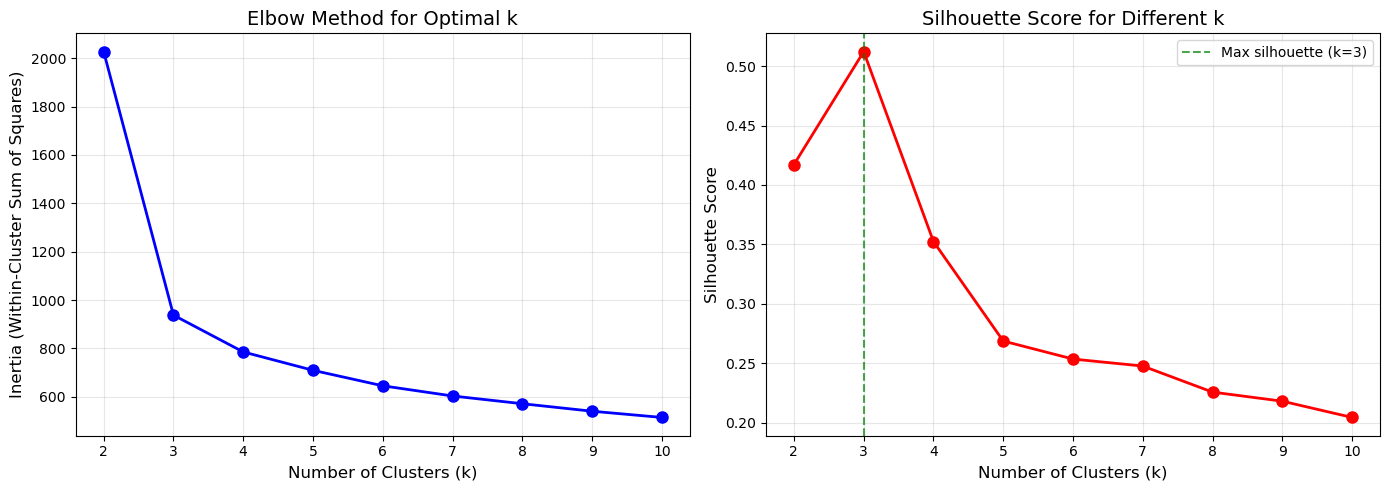


Silhouette score suggests: k = 3 (score: 0.5122)

Selected optimal k: 3


In [14]:
# Determine Best Value for K 

# Standardize the features
scaler = StandardScaler()
credit_scaled = scaler.fit_transform(credit)

print(f"Scaled data shape: {credit_scaled.shape}")
print("\nFeature scaling completed using StandardScaler")

# Calculate inertia and silhouette scores for different k values
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(credit_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(credit_scaled, kmeans.labels_))
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# %%
# Plot elbow curve and silhouette score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different k', fontsize=14)
axes[1].grid(True, alpha=0.3)
max_k = k_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=max_k, color='green', linestyle='--', alpha=0.7, 
                label=f'Max silhouette (k={max_k})')

axes[1].legend()
plt.tight_layout()
plt.show()

# Find best k (using silhouette score as primary criterion)
silhouette_k = k_range[np.argmax(silhouette_scores)]
best_k = silhouette_k

print(f"\nSilhouette score suggests: k = {best_k} (score: {max(silhouette_scores):.4f})")
print(f"\nSelected optimal k: {best_k}")

In [15]:
# Train the model, predict the labels and print the labels of the trained model

# Train the model with optimal k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(credit_scaled)

# Add cluster labels to the dataframe
credit['Cluster'] = cluster_labels

print(f"\nModel trained successfully with k={best_k}")
print(f"\nCluster Labels:")
print(cluster_labels)

print(f"\nCluster label distribution:")
label_counts = pd.Series(cluster_labels).value_counts().sort_index()
for label in range(best_k):
    if label in label_counts.index:
        count = label_counts[label]
        percentage = count/len(cluster_labels)*100
        print(f"  Cluster {label}: {count} customers ({percentage:.1f}%)")


Model trained successfully with k=3

Cluster Labels:
[0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 2 0 1 1 0 1 0 1 0 0 1 2 1 0 0 1 0 1 2 0
 2 0 0 0 1 1 1 0 0 0 0 0 0 2 0 0 0 0 1 1 1 1 0 0 2 1 0 1 1 1 0 0 0 0 0 1 2
 1 0 1 2 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1
 0 0 0 0 0 1 2 0 0 0 1 1 0 0 2 1 1 1 0 1 0 1 1 0 0 0 0 1 2 0 1 0 1 0 0 0 0
 0 0 0 2 0 1 1 2 1 1 1 0 0 1 1 0 0 2 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 2 2 1 0 0
 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 2 0 0 0 2 0 1 0 0 0 0 0 2 1 0 0 0 2 0 1 0 0 0 0 2
 0 1 0 2 1 0 0 0 0 1 0 2 0 0 1 1 1 0 1 1 1 1 1 0 0 0 1 0 0 2 1 1 2 0 0 1 1
 2 1 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 1 2 0 1 0 0 1 0 0 1
 1 1 2 1 1 1 2 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0
 0 0 1 0 0 0 2 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 1 1 1
 0 0 0 1 1 0 0 0 2 0 1 0 0 1 1 0 1 0 1 0 1 1 1

In [16]:
# Print the cluster centres

# Get cluster centres and inverse transform to original scale
cluster_centers_scaled = kmeans_final.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

# Create a DataFrame for better readability
feature_names = [col for col in credit.columns if col != 'Cluster']
centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=feature_names,
    index=[f'Cluster {i}' for i in range(best_k)]
)

print("\nCluster Centres:")
print(centers_df)



Cluster Centres:
            Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  \
Cluster 0   33761.096606            5.514360           3.485640   
Cluster 1   12671.875000            2.426339           0.937500   
Cluster 2  140937.500000            8.833333           0.604167   

           Total_Online_Visits  Total_Calls_Made  
Cluster 0             0.996084          2.006527  
Cluster 1             3.562500          6.834821  
Cluster 2            10.958333          1.062500  


In [17]:
print("\nCluster Centres (rounded):")
print(centers_df.round(2))


Cluster Centres (rounded):
           Credit_Limit  Total_Credit_Cards  Total_Bank_Visits  \
Cluster 0      33761.10                5.51               3.49   
Cluster 1      12671.87                2.43               0.94   
Cluster 2     140937.50                8.83               0.60   

           Total_Online_Visits  Total_Calls_Made  
Cluster 0                 1.00              2.01  
Cluster 1                 3.56              6.83  
Cluster 2                10.96              1.06  


# Visualise the data using the seaborn package

Number of features: 5
Number of scatter plots to create: 10


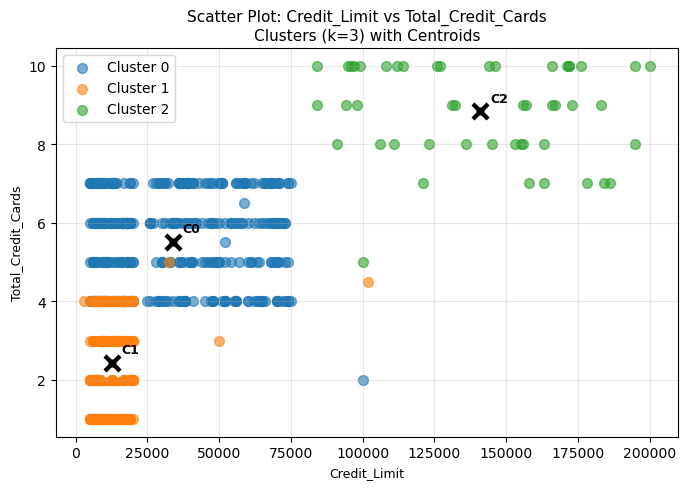

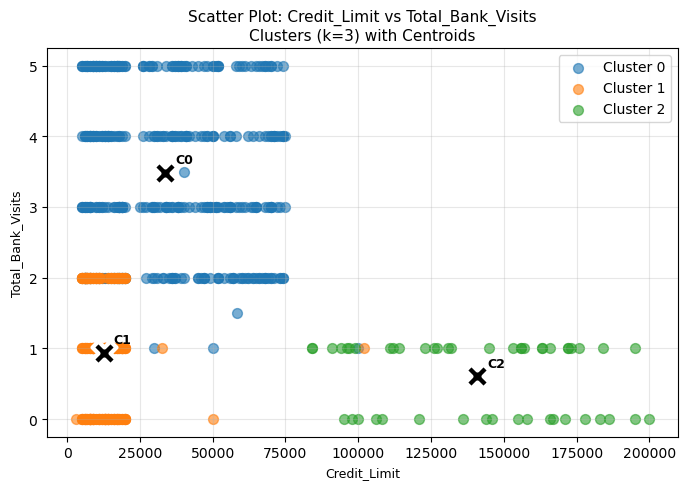

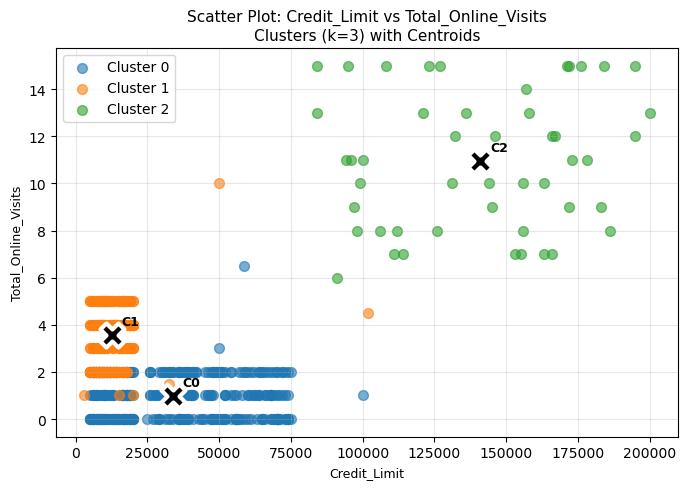

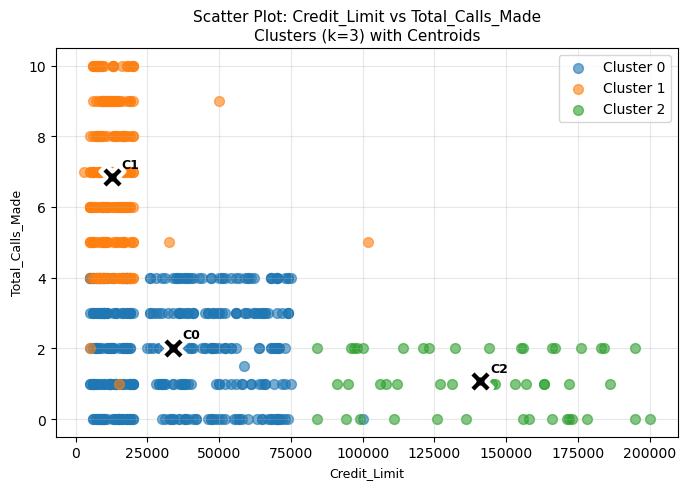

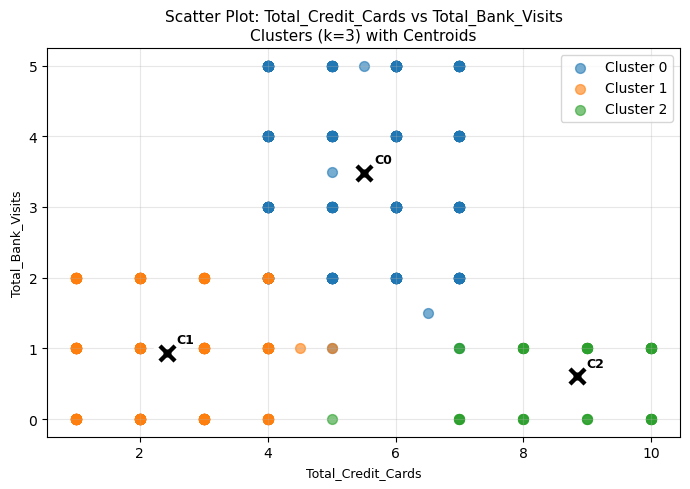

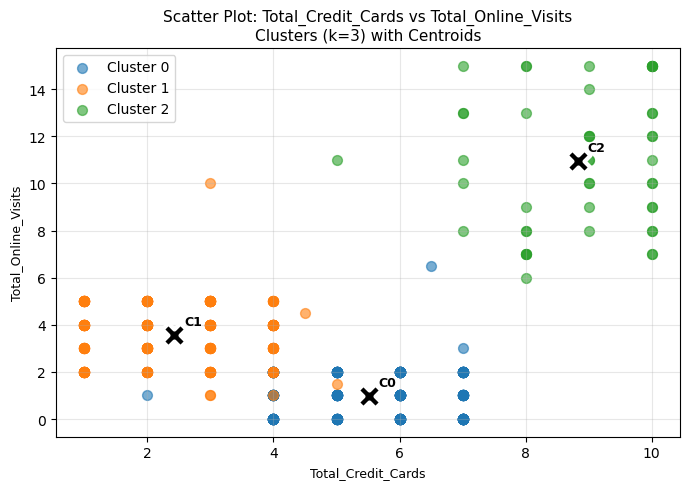

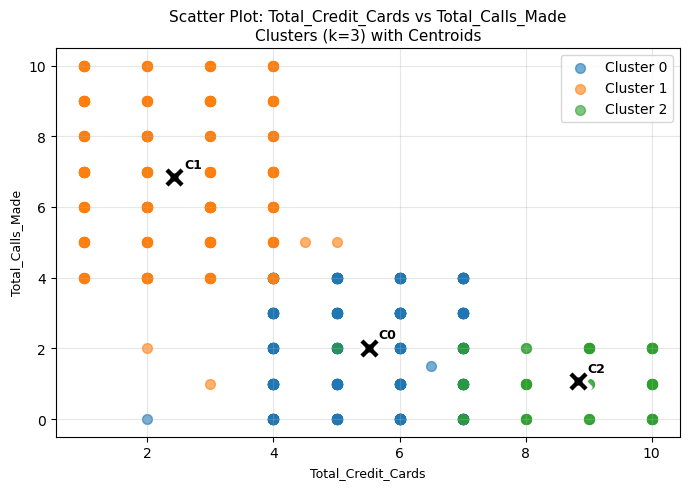

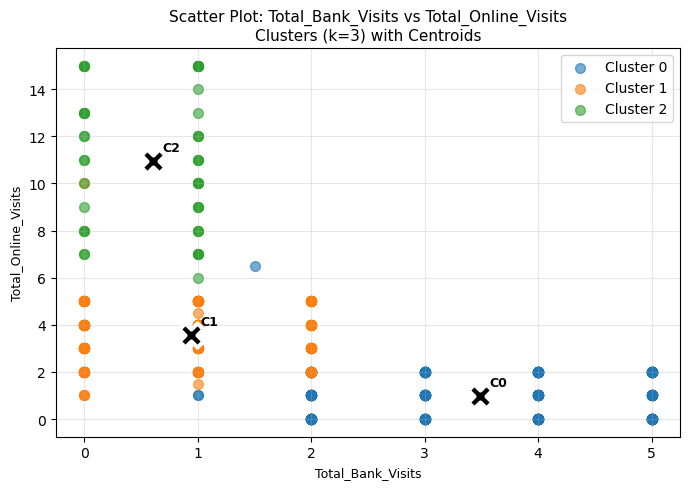

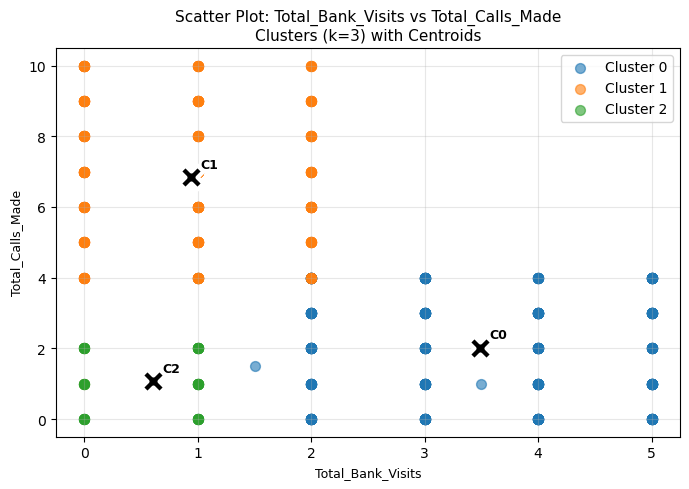

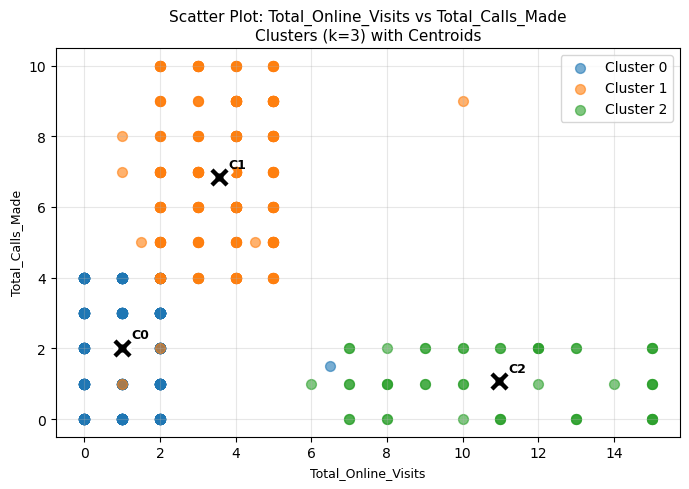

In [18]:
# Get feature names (excluding Cluster)
features = feature_names
n_features = len(features)

print(f"Number of features: {n_features}")
print(f"Number of scatter plots to create: {n_features * (n_features - 1) // 2}")

# Create scatter plots between the different pairs of features
for idx, i in enumerate(range(n_features)):
    for j in range(i+1, n_features):
        plt.figure(figsize=(7, 5))
        
        # Show the clusters that were identified by the model within the data by means of different colours
        for cluster in range(best_k):
            cluster_data = credit[credit['Cluster'] == cluster]
            plt.scatter(cluster_data[features[i]], cluster_data[features[j]], 
                       label=f'Cluster {cluster}', alpha=0.6, s=50)
        
        # Plot centroids of the clusters
        for cluster in range(best_k):
            centroid_x = centers_df.iloc[cluster][features[i]]
            centroid_y = centers_df.iloc[cluster][features[j]]
            plt.scatter(centroid_x, centroid_y, marker='X', s=300, 
                       c='black', edgecolors='white', linewidth=3, zorder=5)
            plt.annotate(f'C{cluster}', (centroid_x, centroid_y), 
                        xytext=(7, 7), textcoords='offset points', 
                        fontsize=9, fontweight='bold')
        
        plt.xlabel(features[i], fontsize=9)
        plt.ylabel(features[j], fontsize=9)
        plt.title(f'Scatter Plot: {features[i]} vs {features[j]}\nClusters (k={best_k}) with Centroids', 
                  fontsize=11)
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# Evaluate and discuss the optimal k-value 

In [19]:
print(f"\n1. Silhouette Score Result: k = {best_k}")
print(f"   The silhouette score for k={best_k} is {max(silhouette_scores):.4f}.")
print(f"   Overall scores ranged from {min(silhouette_scores):.4f} to {max(silhouette_scores):.4f}.")

if max(silhouette_scores) > 0.5:
    print("   This suggests that the clusters are well separated and clearly defined.")
else:
    print("   This suggests that the clusters are moderately separated with some overlap.")

print(f"\n2. Optimal Number of Clusters")
print(f"   Based on the evaluation, k={best_k} was selected as the most suitable")
print("   number of clusters for this dataset.")

print("\n3. Scatter Plot Observations:")
print("   The visualisations show how customers are grouped into different clusters.")

for i in range(best_k):
    if i in label_counts.index:
        cluster_size = len(credit[credit['Cluster'] == i])
        print(f"   - Cluster {i} contains {cluster_size} customers "
              f"({cluster_size/len(credit)*100:.1f}%).")

print("   The cluster centroids are positioned near the centre of their groups,")
print("   although a small amount of overlap can still be observed between")
print("   certain clusters.")

print("\n4. Comparing Silhouette score and Visual Evaluation:")
print("   The silhouette score provides a numerical measure of clustering quality,")
print("   while the scatter plots help visually confirm the separation between")
print("   customer groups.")
print(f"   Both approaches suggest that k={best_k} is a suitable choice for")
print("   segmenting this dataset.")

print("-" * 80)

print(f"The clustering model successfully grouped the credit card customers")
print(f"into {best_k} distinct segments based on characteristics such as")
print("credit limits, number of cards, and channel usage behaviour.")
print("These customer segments can assist the bank in improving targeted")
print("marketing campaigns, customer relationship management, and")
print("personalised financial services.")

print("-" * 80)

print(f"\nTotal customers analysed: {len(credit)}")
print(f"Number of features used: {n_features}")
print(f"Optimal number of clusters: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")


1. Silhouette Score Result: k = 3
   The silhouette score for k=3 is 0.5122.
   Overall scores ranged from 0.2044 to 0.5122.
   This suggests that the clusters are well separated and clearly defined.

2. Optimal Number of Clusters
   Based on the evaluation, k=3 was selected as the most suitable
   number of clusters for this dataset.

3. Scatter Plot Observations:
   The visualisations show how customers are grouped into different clusters.
   - Cluster 0 contains 383 customers (58.5%).
   - Cluster 1 contains 224 customers (34.2%).
   - Cluster 2 contains 48 customers (7.3%).
   The cluster centroids are positioned near the centre of their groups,
   although a small amount of overlap can still be observed between
   certain clusters.

4. Comparing Silhouette score and Visual Evaluation:
   The silhouette score provides a numerical measure of clustering quality,
   while the scatter plots help visually confirm the separation between
   customer groups.
   Both approaches suggest tha

In [20]:
credit.head()

,Credit_Limit,Total_Credit_Cards,Total_Bank_Visits,Total_Online_Visits,Total_Calls_Made,Cluster
0,51000.0,7.0,3.0,2.0,0.0,0
1,12000.0,6.0,5.0,2.0,1.0,0
2,19000.0,2.0,2.0,3.0,4.0,1
3,9000.0,7.0,5.0,0.0,0.0,0
4,38000.0,4.0,3.0,2.0,0.0,0
